[photobleaching_corr] Calculating photobleaching from imaging using control_roi reference region
	using data from frame 15 onwards (10 after roi bleaching)
15.221756378644837
[np.float64(655.079302922743), 0.1, 0.001]
Fit results:
	offset = 638.5957974251818
	amplitude: 0.14999999965228467
	tau: 9.999999744157828
	Fitting error (r2)= 4.7256003898543675e-05
	Fitting goodness (chi2)= 1.0123707129039614
Fitting recovery model
Fit results:
	offset = 0.8870528967200938
	amplitude: -0.5920179186796211
	tau: 0.06563609583569789
	Fitting error (r2)= 0.8832241875248091
	Fitting goodness (chi2)= 1.1627046299434811

FRAP results:
	Half maximum = 10.560457195611553 [s]
	Bleach depth 0.22424736768645123
	Gap Ratio= 8.635978549584833e+18
	Mobile Fraction (uncorrected) = 9.724241312298233e-20 (0.839783393839942)


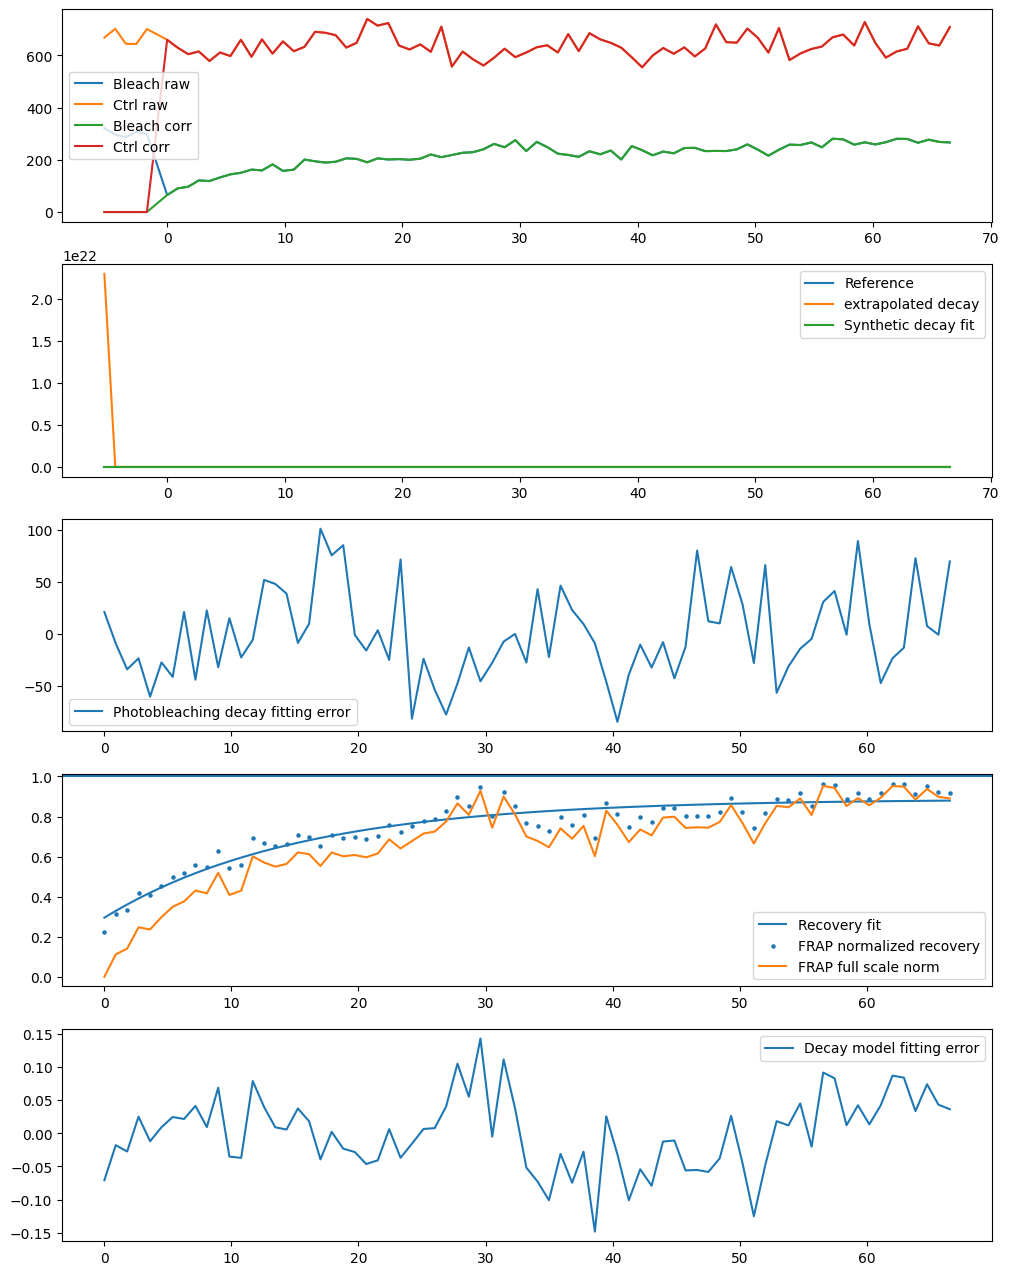

' mdata = CziMetadata(imPath)\nczimd_complete = get_metadata_as_object(imPath)\nmdata_dict = obj2dict(mdata)\ndf_md = misc.md2dataframe(mdata_dict)\n#print(df_md)\n\nfrom pylibCZIrw import czi as pyczi\n\nwith pyczi.open_czi(imPath) as czidoc:\n    md_xml = czidoc.raw_metadata\n    root = ET.fromstring(md_xml)\n    #print(md_xml)\n#meta = img.metadata\nprint("Parsing metadata")sss\nfor child in root:\n    print(child.tag, child.attrib)\n#root = meta\n#ome_meta = img.ome_metadata\n#img.data\nfor neighbor in root.iter(\'RegionItem\'):\n    print(neighbor.attrib)\n\nregions = pd.read_xml(StringIO(md_xml), xpath=".//RegionItem", attrs_only = True, parser="etree")    '

In [40]:
%reload_ext autoreload
%autoreload 2

import tools.io_tools as io_tools
#import tools.processing_tools as processing_tools
import tools.frap_tools as frap_tools
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.patches as patches
from skimage.color import label2rgb 

#import bioio_czi


imPath = "D:\\Projects\\Shannon\\FRAP analysis\\images\\20250115_MeCP2_FRAP_processed\\WT\\dish1_MECP2WT-#roi-05-Airyscan Processing-05.czi"
imPath = "C:\\Users\\amarcosv\\Downloads\\dish1_ASS1WT-#roi-01-proc.czi"
imPath = "D:\Projects\Shannon\FRAP analysis\images\CSV\WT\dish6_0mM_roi1.csv"

imPath = "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250715_WGA_iPSC_SurLab_Ale\\R306C_1mM_NAC\\dish5_iPSC_R306_NAC_roi08.csv"
imPath = "D:\\Projects\\Shannon\\FRAP analysis\\images\\CSV\\20250808_FRAP_2.5D_organoids_WGA_1to2000dil\\dish3_roi12.csv"
imPath = "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250910_WGA_iPSC_Rett_SUR\\WT\\dish1_wt_roi6.csv"

roiData, frap_experiment,a,b = frap_tools.import_FRAP_data(imPath)
#roiData,regions, image, frap_experiment = frap_tools.import_FRAP_data(imPath, False)
roiData, frap_experiment = frap_tools.run_FRAP_analysis(roiData, frap_experiment, 1)

#for region in regions.iterrows():
#    print(region)

#roiData, frap_experiment = processing_tools.photobleaching_corr(roiData, 'control_roi' , frap_experiment, delay = 10,exp=1)

#roiData, frap_experiment = processing_tools.pre_bleach_normalization(roiData,'control_roi' , frap_experiment)

#roiData, frap_experiment = processing_tools.fit_recovery_curve(roiData, frap_experiment, exp=2)




print('\nFRAP results:')
if frap_experiment['recovery_model'].item()==1:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + ' [s]')
else:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + ' [s]')
    print('\tHalf maximum slow = ' + str(frap_experiment['half_max_slow'].item()) + ' [s]')
    print('\tHalf maximum fast = ' + str(frap_experiment['half_max_fast'].item()) + ' [s]')
    
print('\tBleach depth ' + str(frap_experiment['bleach_depth'].item()))
print('\tGap Ratio= ' + str(frap_experiment['gap_ratio'].item()))
print('\tMobile Fraction (uncorrected) = ' + str(frap_experiment['mob_corr'].item()) + ' (' + str(frap_experiment['mob'].item()) + ')')



#rect = patches.Rectangle((100, 100), 50, 50, linewidth=1, edgecolor='r', facecolor="none") 
  

# Add the patch to the Axes 
fig, ax = plt.subplots(5, figsize=(12, 16)) 

#Display sample image after photobleaching


#Plot raw and bleaching corrected data
ax[0].plot(roiData['timestamp_frap'],roiData['bleach'])
ax[0].plot(roiData['timestamp_frap'],roiData['reference'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[0].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'])
ax[0].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_synth'])

ax[0].legend(['Bleach raw', 'Ctrl raw', 'Bleach corr', 'Ctrl corr'])

#Plot photobleaching correction
ax[1].plot(roiData['timestamp_frap'],roiData['reference'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference_synth'])
ax[1].legend(['Reference', 'extrapolated decay', 'Synthetic decay fit'])

#Plot photobleaching correction estimation error
ax[2].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::], 
           roiData['reference'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['reference_decay_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[2].legend(['Photobleaching decay fitting error'])

#Plot photobleaching error
#ax[4].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
#           roiData['bleach_photo_corr_norm'].iloc[frap_experiment.bleach_frame.item() ::], s=5)
#ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           #roiData['reference_photo_corr_norm'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::], s=5)
ax[3].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_fullscale_norm'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].axhline(y=1) 
ax[3].legend([ 'Recovery fit','FRAP normalized recovery', 'FRAP full scale norm'])
#ax[4].legend(['Normalized recovery', 'Recovery fit','FRAP norm', 'FRAP full scale norm'])

ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
          roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[4].legend(['Decay model fitting error'])
#ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::], 
#           roiData['control_wcell'].iloc[frap_experiment.bleach_frame.item() ::])
plt.show() 

#fig, ax2 = plt.subplots( figsize=(12, 10)) 



""" mdata = CziMetadata(imPath)
czimd_complete = get_metadata_as_object(imPath)
mdata_dict = obj2dict(mdata)
df_md = misc.md2dataframe(mdata_dict)
#print(df_md)

from pylibCZIrw import czi as pyczi

with pyczi.open_czi(imPath) as czidoc:
    md_xml = czidoc.raw_metadata
    root = ET.fromstring(md_xml)
    #print(md_xml)
#meta = img.metadata
print("Parsing metadata")sss
for child in root:
    print(child.tag, child.attrib)
#root = meta
#ome_meta = img.ome_metadata
#img.data
for neighbor in root.iter('RegionItem'):
    print(neighbor.attrib)

regions = pd.read_xml(StringIO(md_xml), xpath=".//RegionItem", attrs_only = True, parser="etree")    """


In [ ]:
print(frap_experiment['half_max'].item())
if frap_experiment['recovery_model'].item()==1:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + '[s]')
else:
    print('\tHalf maximum slow = ' + str(frap_experiment['half_max'].item()[0]) + '[s]')
    print('\tHalf maximum fast = ' + str(frap_experiment['half_max'].item()[1]) + '[s]')

In [31]:
plt.plot(roiData['timestamp_frap'],roiData['ref_norm'])
#plt.plot(roiData['timestamp_frap'],roiData['reference_photo_corr'])
#plt.plot(roiData['timestamp_frap'],roiData['reference'])
plt.show()

KeyError: 'ref_norm'

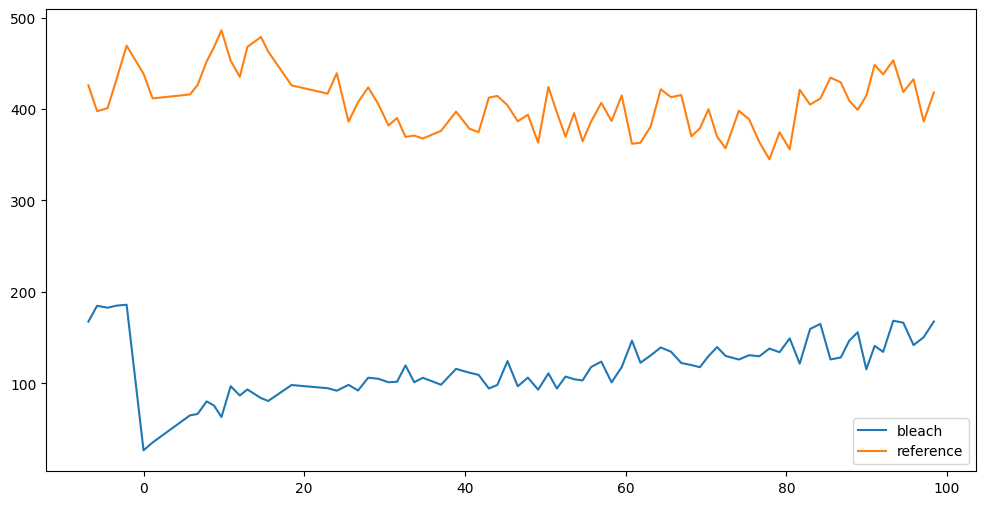

In [33]:


# Add the patch to the Axes 
fig, ax = plt.subplots( figsize=(12, 6)) 

#Display sample image after photobleaching


#Plot raw and bleaching corrected data
plt.plot(roiData['timestamp_frap'],roiData['bleach'],label = 'bleach')
plt.plot(roiData['timestamp_frap'],roiData['reference'],label = 'reference')
plt.legend()
plt.show()


In [35]:
import re
import numpy as np
def parse_intensity_data(file_path):
    """
    Parse a CSV file from Zeiss microscope containing intensities from a FRAP experiment

    Columns to parse:
        Time::Relative Time!!R      --> timestamps
        ChannelX_RY_IntensityMean'  --> intensity mean for region Y in channel X
        Markers::Markers --> find row containing Timed Bleaching and assign it as bleach_frame
    Args:
        file_path (str): The full or relative path to the  CSV file.

    Returns:
        tuple:
            roiData: structure with timepoints, timestamps, bleach and control rois intensities
            blach_frame: timepoint of bleaching event
    """
    try:
        # Read the entire CSV file into a DataFrame.
        # Added a low_memory=False flag which can help with parsing mixed-type columns.
        df = pd.read_csv(file_path, low_memory=False)
    except FileNotFoundError:
        print(f"Error: The file was not found at the specified path: {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
        return None
    
    df = df.drop(0)
    df = df.reset_index()

    roiData = pd.DataFrame()

    # Read timestamp column column
    if 'Time::Relative Time!!R' in df.columns:
        roiData['timestamp'] = df['Time::Relative Time!!R'].copy().astype(float)
        #result_df['timestamp'] = result_df['timestamp'].astype(float)
    else:
        print("Error: 'Time::Relative Time!!R' column not found in the file.")
        return None

    # Parse columns containing intensity mean
    intensity_pattern = re.compile(r'Channel(\d+)_R(\d+)_IntensityMean::')
    found_intensity_columns = False
    intensity_regions = 0
    for col in df.columns:
        match = intensity_pattern.match(col)
        if match:
            found_intensity_columns = True
            # Extract channel (X) and region (Y) numbers.
            channel_num = match.group(1)
            region_num = match.group(2)
            
            # Create a more readable column name.
            new_col_name = f'Channel {channel_num} Region {region_num} Intensity Mean'
            new_col_name = f'region_{intensity_regions}'
            intensity_regions+=1
            
            # Copy the data to our new DataFrame with the new name.
            roiData[new_col_name] = df[col].copy()
    
    if not found_intensity_columns:
        print("Warning: No columns matching the 'ChannelX_RY_IntensityMean' pattern were found.")

    # Process metadata column to identify frap timepoint

    if 'Markers::Markers' in df.columns:
        # Find which row has the string Timed Bleaching in the Markers column
        markers_col = df['Markers::Markers'].astype(str)

        bleach_frame = df.loc[markers_col.str.contains("Timed Bleaching", na=False), 'Markers::Markers'].index.to_numpy()[0]

        roiData.insert(0, 'timepoint', df.index.copy())
        roiData.insert(1, 'timepoint_frap', roiData['timepoint'] - bleach_frame)
        roiData.insert(3, 'timestamp_frap', 
                         roiData['timestamp'] - roiData.loc[bleach_frame, 'timestamp'].item())        

        
        #Identify reference and frap channels using intensity frop after bleach frame
        roi_drops = np.zeros(intensity_regions)
        for i in range(intensity_regions):
          roi_drops[i] =  roiData.loc[bleach_frame,'region_'+ str(i)] / roiData[:bleach_frame]['region_'+ str(i)].mean()
        #Assign largest drop to bleach 
        roiData = roiData.rename(columns={'region_'+str(np.argmin(roi_drops)):'bleach',
                                              'region_'+str(np.argmax(roi_drops)):'control_roi'})

    else:
        print("Warning: 'Markers::Markers' column not found. Skipping bleaching analysis.")

    if roiData.empty:
        print("\nCould not find any rows with 'Timed Bleaching' in the 'Markers::markers' column.")
        return None

    return roiData, bleach_frame



import pandas as pd
roiData, bleach_frame = parse_intensity_data(imPath)
frap_experiment = pd.DataFrame({'bleach_frame':[bleach_frame]}) 
frap_experiment = pd.DataFrame({'bleach_frame':[bleach_frame],'wcell_corr' : [False]}) 


In [56]:
import re
fname = 'dish2_MECP2MUT-#roi-02-Airyscan Processing-19'
dish_pattern = re.compile(r'dish(\d+)')
roi_pattern = re.compile(r'roi(\d+)')
dose_pattern = re.compile(r'(\w+)mM')

params = re.split('[_-]',fname)
dishN = ""
prot = "unknown"
roi = ""

for col in params:
        match = dish_pattern.match(col)
        if match:
            dishN = match.group(1)
            continue 
        
        match = roi_pattern.match(col)
        if match:
              roi = match.group(1)
              continue
        
        match = dose_pattern.match(col)
        if match:
              dose = match.group(1)
              continue    
        if "wt" in col.lower():
            group = "WT" 
            continue

        if "mut" in col.lower():
            group = col
            continue 

print(dishN)
print(roi)
print(dose)  
print(group)      

2

0
MECP2MUT
